# Project 1 - Determinants of Household Income and Wealth (1995 vs 2019)

## Intro and Research Question
How have the determinants of household wealth and household income changed between 1995 and 2019?

### Deciding on Data To Use
I got all data from the PSID variable explorer in which I choose specific variables I thought would be relevant

Years: 1995 vs 2019, near a quarter of a decade of difference and major economy changes made in the 21st century

Output Variables: Total Family Income and House Value are variables I used as the outcome for wealth and household income

Determinants: Age, Marital Status, Race, Home Ownership

Reason: These variables are ones that embody economic status and determine factors of what demographic the person is in.

## Data Loading

First I import libraries we will be using and then I load the data from the PSID custom dataset that I created using the variables mentioned above.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('PSID.csv')


## Basic Data Exploration And Munging:

In [3]:
df.head()

,ER5001,ER5002,ER5006,ER5013,ER5031,ER5032,ER6814,ER6993,ER72001,ER72002,ER72017,ER72024,ER72030,ER72031,ER76897,ER77448
0,6.0,4612.0,72.0,1.0,1.0,60000.0,1.0,11976.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6.0,4231.0,43.0,1.0,1.0,7000.0,1.0,54220.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6.0,6282.0,37.0,4.0,1.0,65000.0,1.0,65900.0,1.0,4574.0,61.0,4.0,5.0,0.0,1.0,11028.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,8597.0,59.0,4.0,1.0,160000.0,1.0,60970.0
4,6.0,5382.0,21.0,2.0,5.0,0.0,1.0,8157.0,1.0,6314.0,45.0,5.0,5.0,0.0,1.0,9380.0


I can see that I have one huge dataframe for both the 1995 and 2019 interviews. Therefore my instinct is to split these into two dataframes one for 2019 and one for 1995. 

## Data Munging - Splitting Data Frame By Year

In [4]:
df_1995_raw = df[['ER5001', 'ER5002', 'ER5006', 'ER5013', 'ER5031', 'ER5032', 'ER6814', 'ER6993']].copy()
df_2019_raw = df[['ER72001', 'ER72002', 'ER72017', 'ER72024', 'ER72030', 'ER72031', 'ER76897', 'ER77448']].copy()

print("Split data into seperate data frames")
print(f'1995 raw: {df_1995_raw.shape}')
print(f'2019 raw: {df_2019_raw.shape}')


Split data into seperate data frames
1995 raw: (17386, 8)
2019 raw: (17386, 8)


## Data Munging - Renaming Columns & Dropping NA Rows
Now I will rename the columns as I do not like them being "ER" IDs as I do not know which coulmn is which just by looking at the data frame.

In [ ]:
df_1995_clean = df_1995_raw.rename(columns={
    'ER5001': 'release_number',
    'ER5002': 'interview_number', 
    'ER5006': 'age',
    'ER5013': 'marital_status',
    'ER5031': 'own_rent_other',
    'ER5032': 'house_value',
    'ER6814': 'race', 
    'ER6993': 'total_family_income'
})

df_2019_clean = df_2019_raw.rename(columns={
    'ER72001': 'release_number',
    'ER72002': 'interview_number',
    'ER72017': 'age',
    'ER72024': 'marital_status',
    'ER72030': 'own_rent_other',
    'ER72031': 'house_value',
    'ER76897': 'race',
    'ER77448': 'total_family_income'
})

df_1995_clean = df_1995_clean.dropna(subset=['age', 'total_family_income', 'house_value'], how='all')
df_2019_clean = df_2019_clean.dropna(subset=['age', 'total_family_income', 'house_value'], how='all')
df_1995_clean['year'] = 1995
df_2019_clean['year'] = 2019
df_1995_clean.head()

,release_number,interview_number,age,marital_status,own_rent_other,house_value,race,total_family_income,year
0,6.0,4612.0,72.0,1.0,1.0,60000.0,1.0,11976.0,1995
1,6.0,4231.0,43.0,1.0,1.0,7000.0,1.0,54220.0,1995
2,6.0,6282.0,37.0,4.0,1.0,65000.0,1.0,65900.0,1995
4,6.0,5382.0,21.0,2.0,5.0,0.0,1.0,8157.0,1995
8,6.0,6364.0,46.0,1.0,1.0,85000.0,1.0,112102.0,1995


## Data Munging - Checking And Changing Data Types

In this section I will check the Data Types and change them if needed to get the data ready for data modeling and machine learning anaylsis.

In [6]:
print("=== 1995 DATA TYPES ===")
print(df_1995_clean.dtypes)
print("\n=== 2019 DATA TYPES ===")
print(df_2019_clean.dtypes)

=== 1995 DATA TYPES ===
release_number         float64
interview_number       float64
age                    float64
marital_status         float64
own_rent_other         float64
house_value            float64
race                   float64
total_family_income    float64
year                     int64
dtype: object

=== 2019 DATA TYPES ===
release_number         float64
interview_number       float64
age                    float64
marital_status         float64
own_rent_other         float64
house_value            float64
race                   float64
total_family_income    float64
year                     int64
dtype: object


I see that the data types are wrong as marital_status, own_rent_other, and race are floats but they should be categories. I am going to make a category key and switch it to categories so the categories are represeted by text in the DFs and are also the correct data type. Based on what I can find from the PSID website, I will transform the values of these floats to categorical strings.

In [7]:
df_1995_clean = df_1995_clean[df_1995_clean['marital_status'].isin([1,2,3,4,5])].copy()
df_2019_clean = df_2019_clean[df_2019_clean['marital_status'].isin([1,2,3,4,5])].copy()

df_1995_clean = df_1995_clean[df_1995_clean['race'].isin([1,2,3,4,5,6,7])].copy()
df_2019_clean = df_2019_clean[df_2019_clean['race'].isin([1,2,3,4,5,6,7])].copy()

df_1995_clean = df_1995_clean[df_1995_clean['own_rent_other'].isin([1,5,8])].copy()
df_2019_clean = df_2019_clean[df_2019_clean['own_rent_other'].isin([1,5,8])].copy()

df_1995_clean.head()
        

,release_number,interview_number,age,marital_status,own_rent_other,house_value,race,total_family_income,year
0,6.0,4612.0,72.0,1.0,1.0,60000.0,1.0,11976.0,1995
1,6.0,4231.0,43.0,1.0,1.0,7000.0,1.0,54220.0,1995
2,6.0,6282.0,37.0,4.0,1.0,65000.0,1.0,65900.0,1995
4,6.0,5382.0,21.0,2.0,5.0,0.0,1.0,8157.0,1995
8,6.0,6364.0,46.0,1.0,1.0,85000.0,1.0,112102.0,1995


Now that I have cleaned the values to only show statuses that matter I will convert to proper data types as well as give them all meaningful and read-able labels.

In [ ]:

for df, year in [(df_1995_clean, "1995"), (df_2019_clean, "2019")]:
    print(f"\nProcessing {year} data...")
    
    if df['race'].dtype in ['float64', 'int64']:
        df['race'] = df['race'].map({
            1: 'White', 2: 'Black', 3: 'Native American', 4: 'Asian', 
            5: 'Latino', 6: 'Other Color', 7: 'Other'
        })
    
    if df['own_rent_other'].dtype in ['float64', 'int64']:
        df['own_rent_other'] = df['own_rent_other'].map({
            1: 'Owns', 5: 'Rents', 8: 'Other'
        })


    if df['marital_status'].dtype in ['float64', 'int64']:
        df['marital_status'] = df['marital_status'].map({
            1: 'Married', 2: 'Never Married', 3: 'Widowed', 4: 'Divorced', 5: 'Separated'
        })

for df in [df_1995_clean, df_2019_clean]:
    df['marital_status'] = df['marital_status'].astype('category')
    df['race'] = df['race'].astype('category')
    df['own_rent_other'] = df['own_rent_other'].astype('category')


print(df_1995_clean.dtypes)
df_1995_clean.head()


Processing 1995 data...

Processing 2019 data...
release_number          float64
interview_number        float64
age                     float64
marital_status         category
own_rent_other         category
house_value             float64
race                   category
total_family_income     float64
year                      int64
dtype: object


,release_number,interview_number,age,marital_status,own_rent_other,house_value,race,total_family_income,year
0,6.0,4612.0,72.0,Married,Owns,60000.0,White,11976.0,1995
1,6.0,4231.0,43.0,Married,Owns,7000.0,White,54220.0,1995
2,6.0,6282.0,37.0,Divorced,Owns,65000.0,White,65900.0,1995
4,6.0,5382.0,21.0,Never Married,Rents,0.0,White,8157.0,1995
8,6.0,6364.0,46.0,Married,Owns,85000.0,White,112102.0,1995


## Data Munging - Final Check
Now I will do some checks on my data to make sure it is ready for anaylsis and machine learning models to be fitted to.

In [9]:
def final_checks(df, year):
    print(f"\n{year} Final Check:")
    print(f"  Total households: {len(df)}")
    print(f"  Missing values: {df.isnull().sum().sum()}")
    print(f"  Mean age: {df['age'].mean():.1f} years")
    print(f"  Mean income: ${df['total_family_income'].mean():,.0f}")
    print(f"  Mean house value: ${df['house_value'].mean():,.0f}")
    print(f"  Home ownership rate: {(df['own_rent_other'] == 'Owns').mean()*100:.1f}%")
    print(f"  Married rate: {(df['marital_status'] == 'Married').mean()*100:.1f}%")

final_checks(df_1995_clean, "1995")
final_checks(df_2019_clean, "2019")

print("\nHouseholds with $0 house value:")
print(f"1995: {(df_1995_clean['house_value'] == 0).sum()} ({(df_1995_clean['house_value'] == 0).mean()*100:.1f}%)")
print(f"2019: {(df_2019_clean['house_value'] == 0).sum()} ({(df_2019_clean['house_value'] == 0).mean()*100:.1f}%)")

print("\nHouseholds with $0 income:")
print(f"1995: {(df_1995_clean['total_family_income'] == 0).sum()} ({(df_1995_clean['total_family_income'] == 0).mean()*100:.1f}%)")
print(f"2019: {(df_2019_clean['total_family_income'] == 0).sum()} ({(df_2019_clean['total_family_income'] == 0).mean()*100:.1f}%)")



1995 Final Check:
  Total households: 10199
  Missing values: 0
  Mean age: 45.0 years
  Mean income: $1,787,484
  Mean house value: $204,780
  Home ownership rate: 54.9%
  Married rate: 51.4%

2019 Final Check:
  Total households: 9485
  Missing values: 0
  Mean age: 46.6 years
  Mean income: $78,025
  Mean house value: $288,076
  Home ownership rate: 50.6%
  Married rate: 43.7%

Households with $0 house value:
1995: 4603 (45.1%)
2019: 4690 (49.4%)

Households with $0 income:
1995: 75 (0.7%)
2019: 143 (1.5%)


I can see that their is an issue with the 1995 final check because the mean income is way too high even compared to the mean house value. The mean income in 2019 is much lower.
## Data Munging - 1995 Income Data Diagnosis

In [ ]:
print("=== INCOME DIAGNOSIS ===")

def diagnose_income(df, year):
    print(f"\n{year} Income Analysis:")
    print(f"Data type: {df['total_family_income'].dtype}")
    print(f"Mean: ${df['total_family_income'].mean():,.0f}")
    print(f"Median: ${df['total_family_income'].median():,.0f}")
    print(f"Min: ${df['total_family_income'].min():,.0f}")
    print(f"Max: ${df['total_family_income'].max():,.0f}")
    print(f"Standard deviation: ${df['total_family_income'].std():,.0f}")
    for p in [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
        print(f"{int(p*100)}th percentile: ${df['total_family_income'].quantile(p):,.0f}")

diagnose_income(df_1995_clean, "1995")
diagnose_income(df_2019_clean, "2019")

=== INCOME DIAGNOSIS ===

1995 Income Analysis:
Data type: float64
Mean: $1,787,484
Median: $39,625
Min: $-122,355
Max: $9,999,999
Standard deviation: $3,786,947
25th percentile: $17,914
50th percentile: $39,625
75th percentile: $87,830
90th percentile: $9,999,999
95th percentile: $9,999,999
99th percentile: $9,999,999

2019 Income Analysis:
Data type: float64
Mean: $78,025
Median: $55,320
Min: $-267,900
Max: $2,125,100
Standard deviation: $89,156
25th percentile: $28,000
50th percentile: $55,320
75th percentile: $100,406
90th percentile: $160,080
95th percentile: $210,441
99th percentile: $392,749


I can see there is an issue because in 1995 there is a huge outlier of 9,999,999$ and also a weird minimum of -122,355. I will deal with these by removing large outlier values from the dataframes and then redo the final check to make sure that my data is fully ready for anaylsis.

In [ ]:
extreme_mask_1995 = df_1995_clean['total_family_income'] == 9999999
extreme_count_1995 = extreme_mask_1995.sum()

extreme_mask_2019 = df_2019_clean['total_family_income'] >= 2000000
extreme_count_2019 = extreme_mask_2019.sum()

print(f"1995 extreme values ($9,999,999): {extreme_count_1995} households")
print(f"2019 extreme values (>$2M): {extreme_count_2019} households")

df_1995_fixed = df_1995_clean[~extreme_mask_1995].copy()
df_2019_fixed = df_2019_clean[~extreme_mask_2019].copy()

print(f"\nAfter removal:")
print(f"1995: {len(df_1995_fixed):,} households (removed {extreme_count_1995})")
print(f"2019: {len(df_2019_fixed):,} households (removed {extreme_count_2019})")

df_1995_clean = df_1995_fixed.copy()
df_2019_clean = df_2019_fixed.copy()

print("✅ Original DataFrames updated with fixed data")

1995 extreme values ($9,999,999): 1788 households
2019 extreme values (>$2M): 1 households

After removal:
1995: 8,411 households (removed 1788)
2019: 9,484 households (removed 1)
✅ Original DataFrames updated with fixed data


## Data Munging - Redoing Final Analysis

In [12]:
def final_checks(df, year):
    print(f"\n{year} Final Check:")
    print(f"  Total households: {len(df)}")
    print(f"  Missing values: {df.isnull().sum().sum()}")
    print(f"  Mean age: {df['age'].mean():.1f} years")
    print(f"  Mean income: ${df['total_family_income'].mean():,.0f}")
    print(f"  Mean house value: ${df['house_value'].mean():,.0f}")
    print(f"  Home ownership rate: {(df['own_rent_other'] == 'Owns').mean()*100:.1f}%")
    print(f"  Married rate: {(df['marital_status'] == 'Married').mean()*100:.1f}%")

final_checks(df_1995_clean, "1995")
final_checks(df_2019_clean, "2019")

print("\nHouseholds with $0 house value:")
print(f"1995: {(df_1995_clean['house_value'] == 0).sum()} ({(df_1995_clean['house_value'] == 0).mean()*100:.1f}%)")
print(f"2019: {(df_2019_clean['house_value'] == 0).sum()} ({(df_2019_clean['house_value'] == 0).mean()*100:.1f}%)")

print("\nHouseholds with $0 income:")
print(f"1995: {(df_1995_clean['total_family_income'] == 0).sum()} ({(df_1995_clean['total_family_income'] == 0).mean()*100:.1f}%)")
print(f"2019: {(df_2019_clean['total_family_income'] == 0).sum()} ({(df_2019_clean['total_family_income'] == 0).mean()*100:.1f}%)")



1995 Final Check:
  Total households: 8411
  Missing values: 0
  Mean age: 44.7 years
  Mean income: $41,678
  Mean house value: $199,089
  Home ownership rate: 56.5%
  Married rate: 50.9%

2019 Final Check:
  Total households: 9484
  Missing values: 0
  Mean age: 46.6 years
  Mean income: $77,809
  Mean house value: $288,107
  Home ownership rate: 50.6%
  Married rate: 43.7%

Households with $0 house value:
1995: 3655 (43.5%)
2019: 4689 (49.4%)

Households with $0 income:
1995: 75 (0.9%)
2019: 143 (1.5%)


## Data Munging - Final Conclusion
In this section I encountered a few problems that I solved when it comes to data munging. The first thing I tackled was splitting the two data frames into data frames as the 1995 and 2019 data were all in one huge data frame and would have NAN for all values in the other year so I split them into two data frames and got rid of all NAN rows in the two new data frames that indicated it was an entry of the other year. Once I split the two data frames I wanted to make them more readable and fix a data type issue where everything was floats even when some of them should have been category data types. I created keys for the values of the category types to turn them into category type with string data types so you can easily read the entries of the data frames. After I did this I did a final analysis of the stats of the data in which I found the 1995 data had a very large mean for family income which I diagnosed as a bunch of entries with the value of 9,999,999$ so I removed them and also removed outliers for the 2019 values of income and did the final analysis again where I can see a change of mean income and mean house value that made since with the 24 year gap of time.

# Deciding How To Answer The Reasearch Question
In this section I must decide how I will answer "Compare and contrast determinants of household income and household wealth and how they may have changed between 1995 and 2019." First I will compare the two years by doing similar tests in both of them such as how the determinants affect income vs wealth and what potential other determinants in my dataframes affect income or wealth stronger than other determinants. To contrast these I will look at how certain relationships between determinants and wealth / income have changed over time and which determinants became more important over time and which determinants became less important over time.

# Choosing Statistical Methods
I will use certain machine learning methods in order to find patterns in the determinants. I will use multiple linear regression in order to have interpretable coeffecients, this will help me answer questions such as "How much do the changes in X affect Y?". I will also use regularized regression in order to find relationships like "which determinants are more important compared to the others?". Random forests can be used to answer questions such as "What is the importance of each determinant?" and finally cross validation to answer questions such as "How well do the models generalize"

# Analysis Section

## Creating Dummy Vars for Regression

In [13]:
def regression_prep(df):
    df_reg = df.copy()

    marital_dummies = pd.get_dummies(df_reg['marital_status'], prefix='marital', drop_first=True)
    race_dummies = pd.get_dummies(df_reg['race'], prefix='race', drop_first=True)
    home_dummies = pd.get_dummies(df_reg['own_rent_other'], prefix='home', drop_first=True)

    df_reg = pd.concat([df_reg, marital_dummies, race_dummies, home_dummies], axis=1)

    return df_reg

df_1995_reg = regression_prep(df_1995_clean)
df_2019_reg = regression_prep(df_2019_clean)

print(f'1995 features: {df_1995_reg.shape[1]}')
print(f'2019 features: {df_2019_reg.shape[1]}')
df_1995_reg.head(n=20)


1995 features: 21
2019 features: 20


,release_number,interview_number,age,marital_status,own_rent_other,house_value,race,total_family_income,year,marital_Married,...,marital_Separated,marital_Widowed,race_Black,race_Latino,race_Native American,race_Other,race_Other Color,race_White,home_Owns,home_Rents
0,6.0,4612.0,72.0,Married,Owns,60000.0,White,11976.0,1995,True,...,False,False,False,False,False,False,False,True,True,False
1,6.0,4231.0,43.0,Married,Owns,7000.0,White,54220.0,1995,True,...,False,False,False,False,False,False,False,True,True,False
2,6.0,6282.0,37.0,Divorced,Owns,65000.0,White,65900.0,1995,False,...,False,False,False,False,False,False,False,True,True,False
4,6.0,5382.0,21.0,Never Married,Rents,0.0,White,8157.0,1995,False,...,False,False,False,False,False,False,False,True,False,True
8,6.0,6364.0,46.0,Married,Owns,85000.0,White,112102.0,1995,True,...,False,False,False,False,False,False,False,True,True,False
9,6.0,7182.0,35.0,Married,Owns,59000.0,White,53000.0,1995,True,...,False,False,False,False,False,False,False,True,True,False
10,6.0,9652.0,28.0,Never Married,Owns,30000.0,White,3999.0,1995,False,...,False,False,False,False,False,False,False,True,True,False
11,6.0,8221.0,51.0,Married,Owns,90000.0,White,106003.0,1995,True,...,False,False,False,False,False,False,False,True,True,False
16,6.0,361.0,51.0,Married,Owns,20000.0,White,28049.0,1995,True,...,False,False,False,False,False,False,False,True,True,False
18,6.0,4137.0,32.0,Married,Owns,25000.0,White,52000.0,1995,True,...,False,False,False,False,False,False,False,True,True,False


In this section I created dummy variables in order to create features for each data frame based on the marital status race and own/rent/other categorical variables. this will allow me to perform multiple regression on these 3 categories in the next section.
## Baseline Linear Regression 1995

In [14]:
feature_columns = [
    'age',
    'marital_Married', 'marital_Widowed', 'marital_Separated',
    'race_Black', 'race_Native American', 'race_Latino', 'race_Other Color', 'race_Other',
    'home_Owns', 'home_Rents'
]

X_1995_income = df_1995_reg[feature_columns]
y_1995_income = df_1995_reg['total_family_income']

model_1995_income = LinearRegression()
model_1995_income.fit(X_1995_income, y_1995_income)

X_1995_wealth = df_1995_reg[feature_columns]
y_1995_wealth = df_1995_reg['house_value']

model_1995_wealth = LinearRegression()
model_1995_wealth.fit(X_1995_wealth, y_1995_wealth)

results_1995 = pd.DataFrame({
    'Feature': feature_columns,
    'Income_Coefficient': model_1995_income.coef_,
    'Wealth_Coefficient': model_1995_wealth.coef_,
    'Difference': model_1995_wealth.coef_ - model_1995_income.coef_
})


## Baseline Regression 2019

In [15]:
feature_columns = [
    'age',
    'marital_Married', 'marital_Widowed', 'marital_Separated',
    'race_Black', 'race_Native American', 'race_Latino', 'race_Other',
    'home_Owns', 'home_Rents'
]

X_2019_income = df_2019_reg[feature_columns]
y_2019_income = df_2019_reg['total_family_income']

model_2019_income = LinearRegression()
model_2019_income.fit(X_2019_income, y_2019_income)

X_2019_wealth = df_2019_reg[feature_columns]
y_2019_wealth = df_2019_reg['house_value']

model_2019_wealth = LinearRegression()
model_2019_wealth.fit(X_2019_wealth, y_2019_wealth)

results_2019 = pd.DataFrame({
    'Feature': feature_columns,
    'Income_Coefficient': model_2019_income.coef_,
    'Wealth_Coefficient': model_2019_wealth.coef_,
    'Difference': model_2019_wealth.coef_ - model_2019_income.coef_
})


## Visualizing The Comparisons

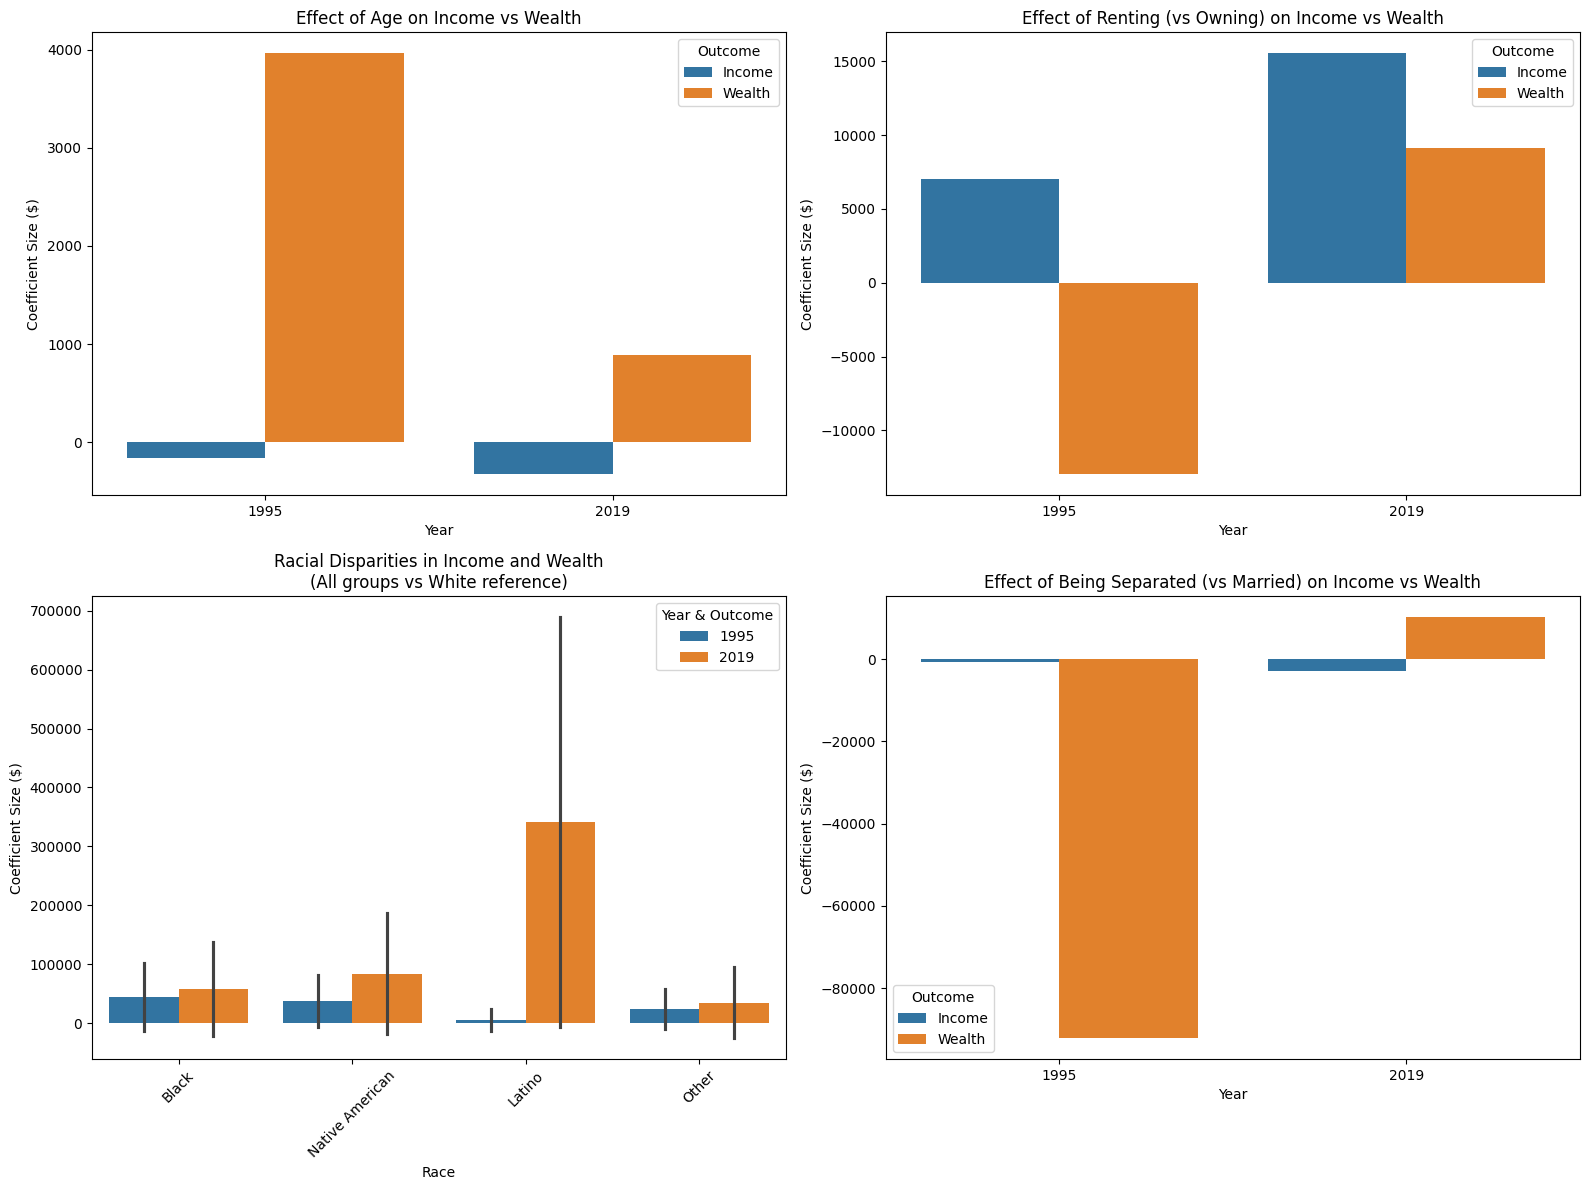

Age coefficient: $-159
Renting coefficient: $7,052

Black coefficient: $-12,728
  Black households earn $12,728 less than White households

Native American coefficient: $-6,402
  Native American households earn $6,402 less than White households

Latino coefficient: $-13,606
  Latino households earn $13,606 less than White households

Other coefficient: $-9,230
  Other households earn $9,230 less than White households

• Largest income disparity: Latino households ($13,606 less than White households)
• Renting penalty: $7,052 income gap
• Racial disparities range from $6,402 to $13,606


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

age_data = pd.DataFrame({
    'Year': ['1995', '2019', '1995', '2019'],
    'Outcome': ['Income', 'Income', 'Wealth', 'Wealth'],
    'Age_Coefficient': [
        results_1995[results_1995['Feature'] == 'age']['Income_Coefficient'].iloc[0],
        results_2019[results_2019['Feature'] == 'age']['Income_Coefficient'].iloc[0],
        results_1995[results_1995['Feature'] == 'age']['Wealth_Coefficient'].iloc[0],
        results_2019[results_2019['Feature'] == 'age']['Wealth_Coefficient'].iloc[0]
    ]
})

sns.barplot(data=age_data, x='Year', y='Age_Coefficient', hue='Outcome', ax=axes[0,0])
axes[0,0].set_title('Effect of Age on Income vs Wealth')
axes[0,0].set_ylabel('Coefficient Size ($)')


renting_effect = pd.DataFrame({
    'Year': ['1995', '2019', '1995', '2019'],
    'Outcome': ['Income', 'Income', 'Wealth', 'Wealth'],
    'Renting_Coefficient': [
        results_1995[results_1995['Feature'] == 'home_Rents']['Income_Coefficient'].iloc[0],
        results_2019[results_2019['Feature'] == 'home_Rents']['Income_Coefficient'].iloc[0],
        results_1995[results_1995['Feature'] == 'home_Rents']['Wealth_Coefficient'].iloc[0],
        results_2019[results_2019['Feature'] == 'home_Rents']['Wealth_Coefficient'].iloc[0]
    ]
})

sns.barplot(data=renting_effect, x='Year', y='Renting_Coefficient', hue='Outcome', ax=axes[0,1])
axes[0,1].set_title('Effect of Renting (vs Owning) on Income vs Wealth')
axes[0,1].set_ylabel('Coefficient Size ($)')


race_features_1995 = [f for f in results_1995['Feature'] if f.startswith('race_')]
race_features_2019 = [f for f in results_2019['Feature'] if f.startswith('race_')]
common_race_features = list(set(race_features_1995) & set(race_features_2019))

race_data = []
for race_feature in common_race_features:
    race_name = race_feature.replace('race_', '')  
    
    race_data.append({
        'Race': race_name,
        'Year': '1995',
        'Outcome': 'Income',
        'Coefficient': results_1995[results_1995['Feature'] == race_feature]['Income_Coefficient'].iloc[0]
    })
    race_data.append({
        'Race': race_name,
        'Year': '1995', 
        'Outcome': 'Wealth',
        'Coefficient': results_1995[results_1995['Feature'] == race_feature]['Wealth_Coefficient'].iloc[0]
    })

    race_data.append({
        'Race': race_name,
        'Year': '2019',
        'Outcome': 'Income',
        'Coefficient': results_2019[results_2019['Feature'] == race_feature]['Income_Coefficient'].iloc[0]
    })
    race_data.append({
        'Race': race_name,
        'Year': '2019',
        'Outcome': 'Wealth',
        'Coefficient': results_2019[results_2019['Feature'] == race_feature]['Wealth_Coefficient'].iloc[0]
    })

race_df = pd.DataFrame(race_data)

sns.barplot(data=race_df, x='Race', y='Coefficient', hue='Year', ax=axes[1,0])
axes[1,0].set_title('Racial Disparities in Income and Wealth\n(All groups vs White reference)')
axes[1,0].set_ylabel('Coefficient Size ($)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(title='Year & Outcome')

single_effect = pd.DataFrame({
    'Year': ['1995', '2019', '1995', '2019'],
    'Outcome': ['Income', 'Income', 'Wealth', 'Wealth'],
    'Single_Coefficient': [
        results_1995[results_1995['Feature'] == 'marital_Separated']['Income_Coefficient'].iloc[0],
        results_2019[results_2019['Feature'] == 'marital_Separated']['Income_Coefficient'].iloc[0],
        results_1995[results_1995['Feature'] == 'marital_Separated']['Wealth_Coefficient'].iloc[0],
        results_2019[results_2019['Feature'] == 'marital_Separated']['Wealth_Coefficient'].iloc[0]
    ]
})

sns.barplot(data=single_effect, x='Year', y='Single_Coefficient', hue='Outcome', ax=axes[1,1])
axes[1,1].set_title('Effect of Being Separated (vs Married) on Income vs Wealth')
axes[1,1].set_ylabel('Coefficient Size ($)')

plt.tight_layout()
plt.show()

age_coef = results_1995[results_1995['Feature'] == 'age']['Income_Coefficient'].iloc[0]
print(f"Age coefficient: ${age_coef:,.0f}")

rent_coef = results_1995[results_1995['Feature'] == 'home_Rents']['Income_Coefficient'].iloc[0]
print(f"Renting coefficient: ${rent_coef:,.0f}")

print()

for race_feature in common_race_features:
    race_name = race_feature.replace('race_', '')
    race_coef = results_1995[results_1995['Feature'] == race_feature]['Income_Coefficient'].iloc[0]
    
    if race_coef < 0:
        print(f"{race_name} coefficient: ${race_coef:,.0f}")
        print(f"  {race_name} households earn ${abs(race_coef):,.0f} less than White households")
    else:
        print(f"{race_name} coefficient: ${race_coef:,.0f}")
        print(f"  {race_name} households earn ${race_coef:,.0f} more than White households")
    print()


largest_gap_race = None
largest_gap_value = 0

for race_feature in common_race_features:
    race_name = race_feature.replace('race_', '')
    race_coef = results_1995[results_1995['Feature'] == race_feature]['Income_Coefficient'].iloc[0]
    gap_size = abs(race_coef)
    
    if gap_size > largest_gap_value:
        largest_gap_value = gap_size
        largest_gap_race = race_name

if largest_gap_race:
    print(f"• Largest income disparity: {largest_gap_race} households (${largest_gap_value:,.0f} less than White households)")
    
print(f"• Renting penalty: ${abs(rent_coef):,.0f} income gap")
print(f"• Racial disparities range from ${min([abs(results_1995[results_1995['Feature'] == rf]['Income_Coefficient'].iloc[0]) for rf in common_race_features]):,.0f} to ${largest_gap_value:,.0f}")

This gives us a ton of insights. I will dig deeper into the age coeffecient issue because obviously -159$ does not seem accurate. But the rest of them do make sense, we can see race plays a huge role into income for different households. Compared to white people, all minorities on average make much less money. Latino being the highest disparity shows a lot about how race is a determinant for family income. Also renting coeffecient has a 7052$ income gap between home ownership. This makes sense as owning home is usually an indicator of a stronger financial situation compared to renting a home.

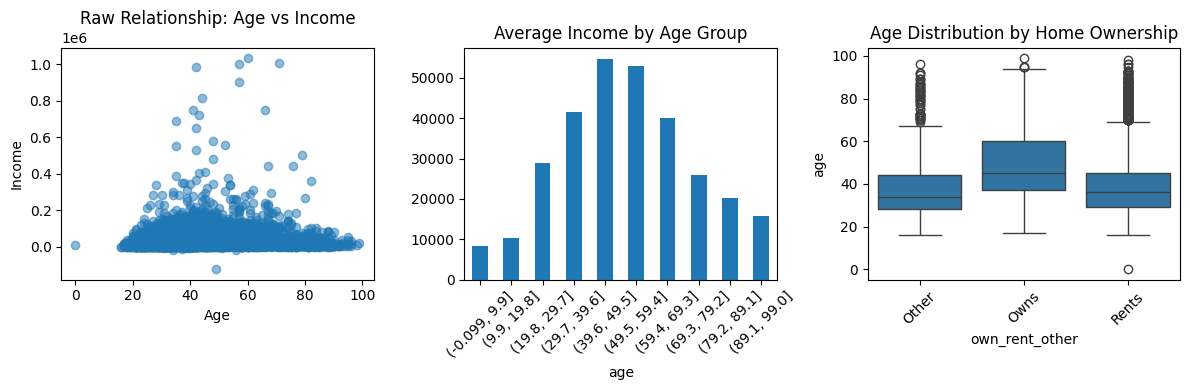

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(df_1995_fixed['age'], df_1995_fixed['total_family_income'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Raw Relationship: Age vs Income')
plt.subplot(1, 3, 2)
age_bins = pd.cut(df_1995_fixed['age'], bins=10)
age_income_means = df_1995_fixed.groupby(age_bins)['total_family_income'].mean()
age_income_means.plot(kind='bar')
plt.title('Average Income by Age Group')
plt.xticks(rotation=45)
plt.subplot(1, 3, 3)
sns.boxplot(data=df_1995_fixed, x='own_rent_other', y='age')
plt.title('Age Distribution by Home Ownership')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Looking at these charts, it is obvious the age coeffecient being negaive was wrong. We can see that it is like a bell curve and that age is a determinant for income as middle aged people typically make the most while young and old people make less. As you approach middle age and grow older than middle age your income is less than would you would make around the ages of 40-60 on average for the head of the household. Also we can see age is a determinant as well for owning and renting a house because renting has a younger mean age than owning a home does.

## Comparing Determinants
In this section I want to compare the determinants with a data visualization that shows the amount of impact a determinant has on Income side by side with which determinants affect wealth. With this side by side visualization we can directly compare the determinants to see which ones have an impact on wealth as well as which ones have an impact on total family income.

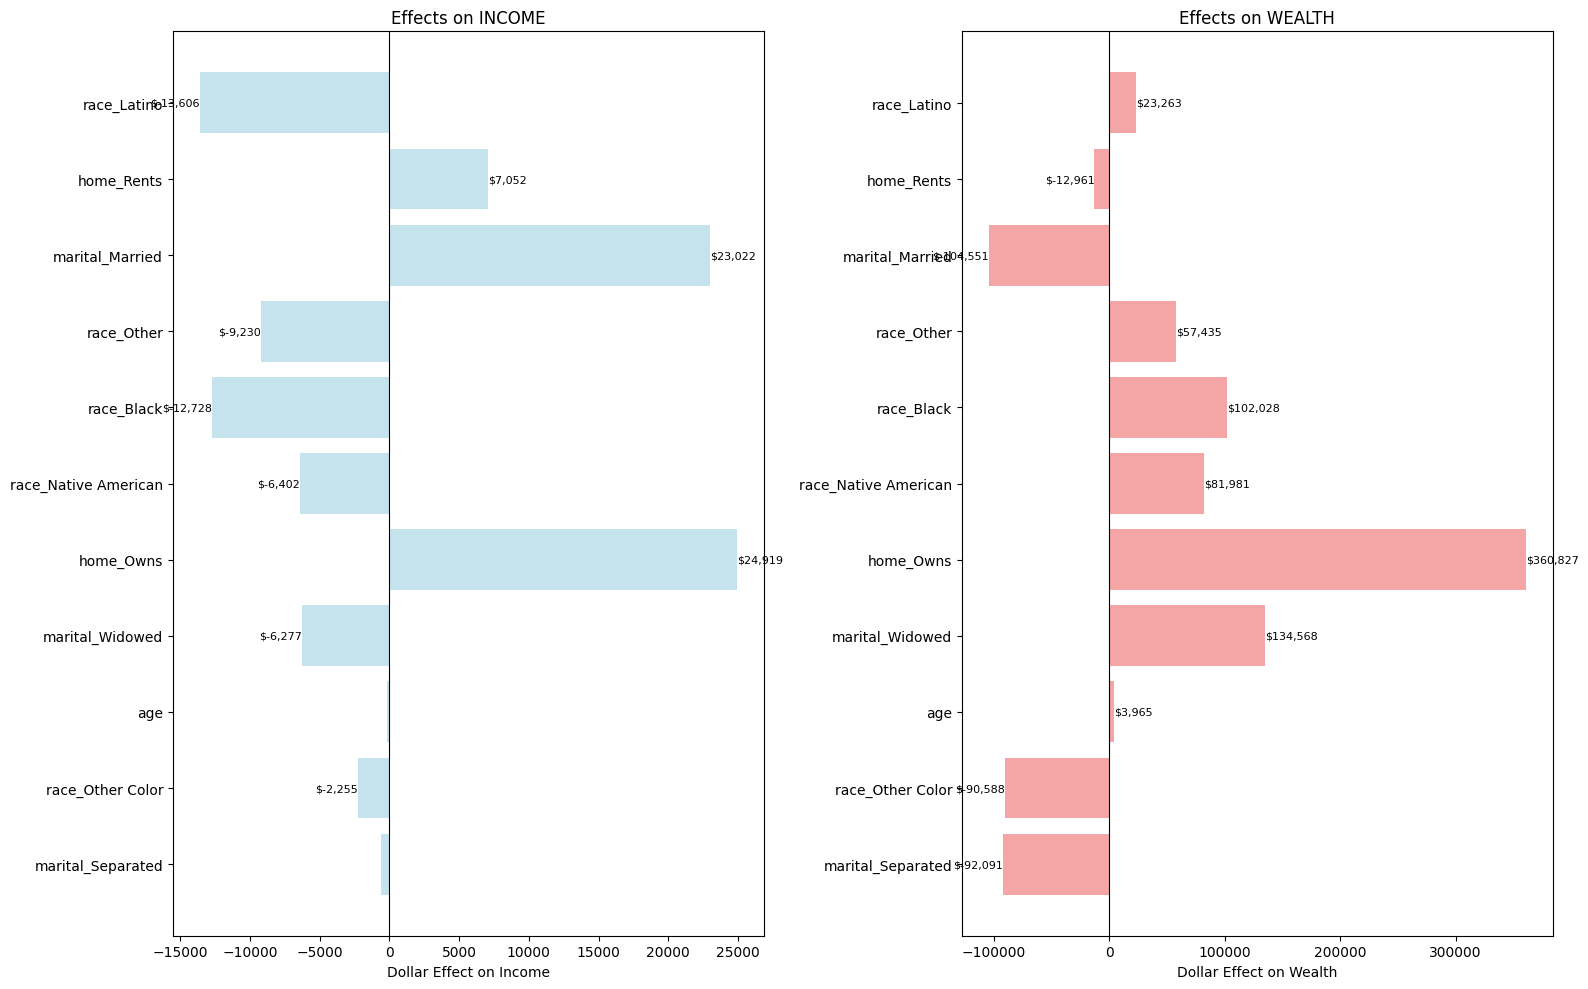

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

income_bars = ax1.barh(plot_df['Feature'], plot_df['Income_Effect'], 
                       color='lightblue', alpha=0.7, label='Income Effect')
ax1.set_xlabel('Dollar Effect on Income')
ax1.set_title('Effects on INCOME')
ax1.axvline(x=0, color='black', linewidth=0.8)

wealth_bars = ax2.barh(plot_df['Feature'], plot_df['Wealth_Effect'], 
                       color='lightcoral', alpha=0.7, label='Wealth Effect')
ax2.set_xlabel('Dollar Effect on Wealth')
ax2.set_title('Effects on WEALTH')
ax2.axvline(x=0, color='black', linewidth=0.8)

for ax, bars in [(ax1, income_bars), (ax2, wealth_bars)]:
    for bar in bars:
        width = bar.get_width()
        if abs(width) > 1000: 
            ax.text(width, bar.get_y() + bar.get_height()/2, 
                   f'${width:,.0f}', ha='left' if width > 0 else 'right', 
                   va='center', fontsize=8)

plt.tight_layout()
plt.show()

In these graphs you can see that being part of a race other than white has a negative impact on income but a positive impact on wealth. I imagine this is because lots of people in other races besides white focus on home ownership and amassing wealth and assets rather than renting a house and spending their income while focusing on having a high income. We can see that for both income and wealth owning a home is the largest indicator of financial success. In both income and wealth age is not a big factor as it is a bell curve so it peaks in the middle and has an even rate of dispersing on either end therefore averaging it creates a practically 0 affect ovearll. In both income and wealth we can see that being married is a huge indicator of financial status as you usually are forced to provide for your spouse and your kids as a man that is married while being separated is a sign of loss of wealth and loss of income.

# Contrast Section
Now that I have compared the different determinants to see how they affected wealth and total family income, I want to contrast how they evolved over time between my two time periods. For this section I will be using Regularized Regression and Random forests. This will show the realtive importance of determinants over time as well as how the importance of determinants shifted over time.

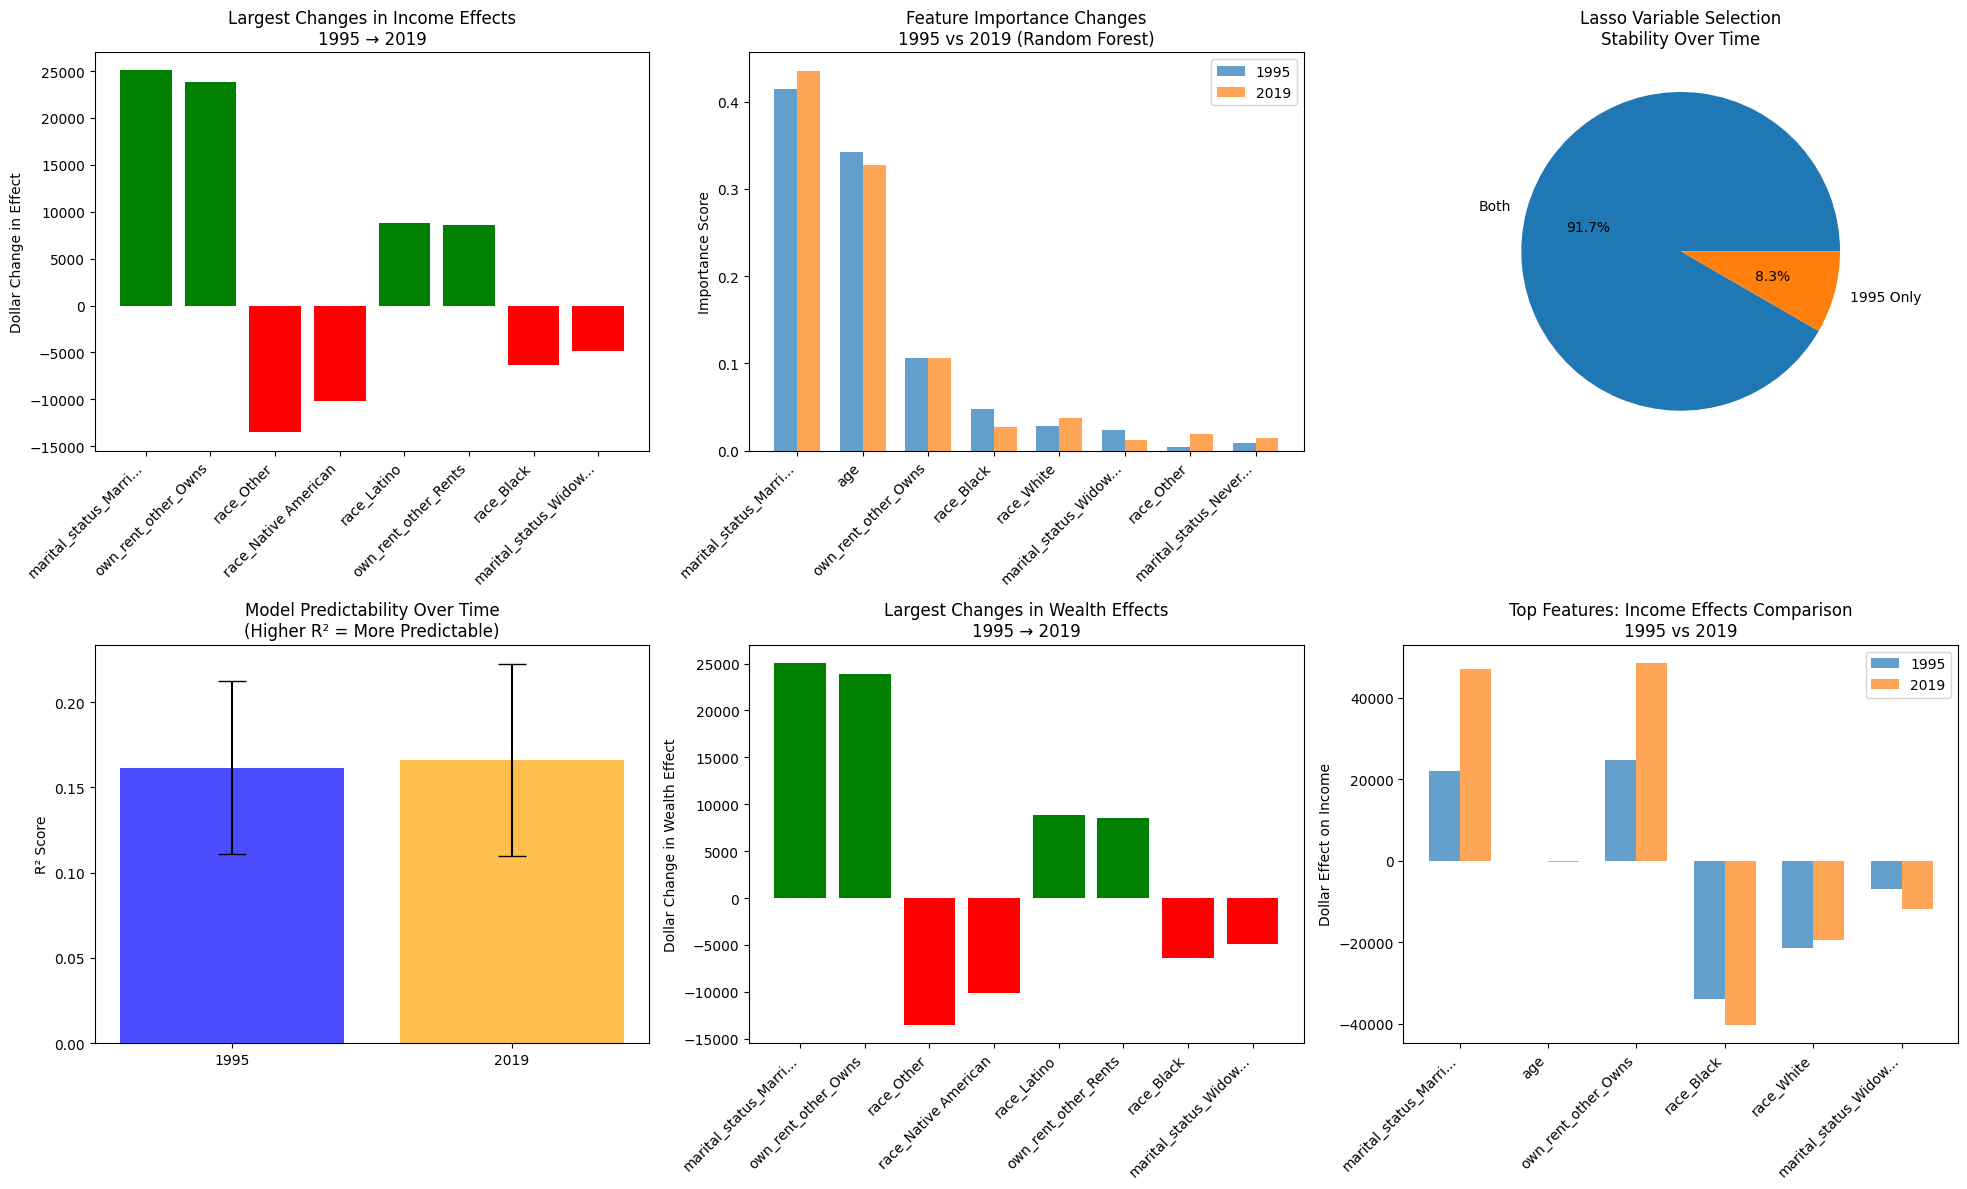

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

def prepare_numeric_features(df):
    df_num = df[['age', 'total_family_income', 'house_value']].copy()
    for col in ['marital_status', 'race', 'own_rent_other']:
        if col in df.columns:
            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
            df_num = pd.concat([df_num, dummies], axis=1)
    return df_num

df_1995_num = prepare_numeric_features(df_1995_fixed)
df_2019_num = prepare_numeric_features(df_2019_fixed)

common_features = list(set(df_1995_num.columns) & set(df_2019_num.columns))
common_features = [f for f in common_features if f not in ['total_family_income', 'house_value']]

X_1995_income = df_1995_num[common_features]
y_1995_income = df_1995_num['total_family_income']
X_2019_income = df_2019_num[common_features]
y_2019_income = df_2019_num['total_family_income']

model_1995_income = LinearRegression()
model_2019_income = LinearRegression()
model_1995_income.fit(X_1995_income, y_1995_income)
model_2019_income.fit(X_2019_income, y_2019_income)

results_1995 = pd.DataFrame({
    'Feature': common_features,
    'Income_Coefficient_1995': model_1995_income.coef_,
    'Income_Coefficient_2019': model_2019_income.coef_
})

time_changes = []
for feature in common_features:
    coef_1995 = results_1995[results_1995['Feature'] == feature]['Income_Coefficient_1995'].iloc[0]
    coef_2019 = results_1995[results_1995['Feature'] == feature]['Income_Coefficient_2019'].iloc[0]
    time_changes.append({
        'Feature': feature,
        'Change_1995_2019': coef_2019 - coef_1995,
        'Abs_Change': abs(coef_2019 - coef_1995)
    })

changes_df = pd.DataFrame(time_changes)
largest_changes = changes_df.nlargest(8, 'Abs_Change')
x = range(len(largest_changes))
feature_names = [name[:20] + '...' if len(name) > 20 else name for name in largest_changes['Feature']]
colors = ['green' if x > 0 else 'red' for x in largest_changes['Change_1995_2019']]
axes[0,0].bar(x, largest_changes['Change_1995_2019'], color=colors)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(feature_names, rotation=45, ha='right')
axes[0,0].set_title('Largest Changes in Income Effects\n1995 → 2019')
axes[0,0].set_ylabel('Dollar Change in Effect')

rf_1995 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_2019 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_1995.fit(X_1995_income, y_1995_income)
rf_2019.fit(X_2019_income, y_2019_income)

importance_comparison = []
for i, feature in enumerate(common_features):
    imp_1995 = rf_1995.feature_importances_[i]
    imp_2019 = rf_2019.feature_importances_[i]
    importance_comparison.append({
        'Feature': feature,
        '1995': imp_1995,
        '2019': imp_2019,
        'Change': imp_2019 - imp_1995
    })

importance_df = pd.DataFrame(importance_comparison)
importance_df['Avg_Importance'] = (importance_df['1995'] + importance_df['2019']) / 2
top_importance = importance_df.nlargest(8, 'Avg_Importance')

x = range(len(top_importance))
width = 0.35
axes[0,1].bar(x, top_importance['1995'], width, label='1995', alpha=0.7)
axes[0,1].bar([i + width for i in x], top_importance['2019'], width, label='2019', alpha=0.7)
axes[0,1].set_xticks([i + width/2 for i in x])
axes[0,1].set_xticklabels([name[:20] + '...' if len(name) > 20 else name for name in top_importance['Feature']], 
                         rotation=45, ha='right')
axes[0,1].set_title('Feature Importance Changes\n1995 vs 2019 (Random Forest)')
axes[0,1].set_ylabel('Importance Score')
axes[0,1].legend()

lasso_1995 = LassoCV(cv=5, random_state=42)
lasso_2019 = LassoCV(cv=5, random_state=42)
lasso_1995.fit(X_1995_income, y_1995_income)
lasso_2019.fit(X_2019_income, y_2019_income)

lasso_stability = []
for i, feature in enumerate(common_features):
    coef_1995 = lasso_1995.coef_[i]
    coef_2019 = lasso_2019.coef_[i]
    status = 'Both' if coef_1995 != 0 and coef_2019 != 0 else '1995 Only' if coef_1995 != 0 else '2019 Only' if coef_2019 != 0 else 'Neither'
    lasso_stability.append(status)

stability_counts = pd.Series(lasso_stability).value_counts()
axes[0,2].pie(stability_counts.values, labels=stability_counts.index, autopct='%1.1f%%')
axes[0,2].set_title('Lasso Variable Selection\nStability Over Time')

cv_1995 = cross_val_score(model_1995_income, X_1995_income, y_1995_income, cv=5, scoring='r2')
cv_2019 = cross_val_score(model_2019_income, X_2019_income, y_2019_income, cv=5, scoring='r2')

years = ['1995', '2019']
performance = [cv_1995.mean(), cv_2019.mean()]
errors = [cv_1995.std(), cv_2019.std()]
axes[1,0].bar(years, performance, yerr=errors, capsize=10, alpha=0.7, color=['blue', 'orange'])
axes[1,0].set_title('Model Predictability Over Time\n(Higher R² = More Predictable)')
axes[1,0].set_ylabel('R² Score')

wealth_changes = []
for feature in common_features:
    wealth_1995 = model_1995_income.coef_[common_features.index(feature)]
    wealth_2019 = model_2019_income.coef_[common_features.index(feature)]
    wealth_changes.append({
        'Feature': feature,
        'Wealth_Effect_1995': wealth_1995,
        'Wealth_Effect_2019': wealth_2019,
        'Wealth_Change': wealth_2019 - wealth_1995
    })

wealth_df = pd.DataFrame(wealth_changes)
wealth_df['Abs_Wealth_Change'] = wealth_df['Wealth_Change'].abs()
largest_wealth_changes = wealth_df.nlargest(8, 'Abs_Wealth_Change')

x = range(len(largest_wealth_changes))
colors_wealth = ['green' if x > 0 else 'red' for x in largest_wealth_changes['Wealth_Change']]
axes[1,1].bar(x, largest_wealth_changes['Wealth_Change'], color=colors_wealth)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels([name[:20] + '...' if len(name) > 20 else name for name in largest_wealth_changes['Feature']], 
                         rotation=45, ha='right')
axes[1,1].set_title('Largest Changes in Wealth Effects\n1995 → 2019')
axes[1,1].set_ylabel('Dollar Change in Wealth Effect')

top_features = importance_df.nlargest(6, 'Avg_Importance')['Feature']
comparison_data = []
for feature in top_features:
    row_1995 = results_1995[results_1995['Feature'] == feature].iloc[0]
    comparison_data.append({
        'Feature': feature,
        '1995_Income': row_1995['Income_Coefficient_1995'],
        '2019_Income': row_1995['Income_Coefficient_2019']
    })

comparison_df = pd.DataFrame(comparison_data)
x = np.arange(len(comparison_df))
width = 0.35
axes[1,2].bar(x - width/2, comparison_df['1995_Income'], width, label='1995', alpha=0.7)
axes[1,2].bar(x + width/2, comparison_df['2019_Income'], width, label='2019', alpha=0.7)
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels([name[:20] + '...' if len(name) > 20 else name for name in comparison_df['Feature']], 
                         rotation=45, ha='right')
axes[1,2].set_title('Top Features: Income Effects Comparison\n1995 vs 2019')
axes[1,2].set_ylabel('Dollar Effect on Income')
axes[1,2].legend()

plt.tight_layout()
plt.show()

## Feature Importance Over Time Analysis
So from chart 1 we can see that the most important determinants over time of income and welath was home ownership and being married. Being latino or renting a home was also a determinant which carried well over time but not as much as the others. As we can see from the second chart, (feature importance changes) every feature remained important through the years as the gaps between the blue and orange bars are very small showing that through both time periods the determinants retained their level of importance. We can see by the pie chart of lasso variable selection that there was a determinant from 1995 that lost importance over time but overall almost every determinant carried well into the future. 

## Income and Wealth Effects Over Time Analysis
From the model predictability over time bar chart we can see that it also did not change much meaning income as steadily as predictable in both years by these determinants. We can see the largest changes in wealth effects are the exact same as the largest changes in income effects over time, showing that features that I used are able to predict both wealth and income as being largely the same (I.E if someone has a certain level of wealth and other determinants you can predict their wealth.) From the last chart we can see top features. We can see that being married and owning house are the top predictors of financial stability and high income as the other indicators like age and being a minority have an overall negative impact on Income and Wealth.

# Conclusion

Using multiple regression, random forests, and lasso regularization I was able to compare and contrast how determinants of race, age, marital status, and home ownership / renter status factored into a family's wealth and total income. From my conclusions I found that over time, the determinants largely stayed the same and were just as effective at predicting a family's wealth and total income in both time periods. Although both family income and total wealth increased between the two times, most of the determinants and factors used to predict a family's total wealth and income largely remained the same. I found that the most important determinants of high family total income and wealth were owning a home as well as being married while race and age did not play nearly as much of a factor. Because age is a bell curve of income, it cannot really be used as a determinant as on average everyone had the same curve of making the least money when they were between 20-40 and 60+ while making their most money between 40-60. Race was not applicable because nearly every other race had a disparity between white people and it was about the same so it was not a very important deterministic and also white people generally had higher income but less total wealth. 